In [3]:
with open("/content/drive/MyDrive/Ciencia-Datos/Ulibro/charlaUlibro.txt", "r", encoding="utf-8") as archivo:
  discurso = archivo.read()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
print(discurso[:500])

...productor y escritor, reconocido por construir narrativas de gran fuerza visual y personajes intensos. En 2010 recibió el Premio Mundial Juvenal por salvar el juego. Entre sus obras también se encuentran Escuadrón Guillotina, El Museo de los Muertos, El Confuerzo de la Noche, El Salvaje, Extraños y El Hombre.

Mateo Gallino, el director de cine colombiano y el director creativo de la productora salsateriana Juan Lluís. Ha escrito y dirigido varios cortometrajes. En 2024 co-dirigió la serie do


In [5]:
len(discurso)

14540

In [ ]:
discurso = discurso.lower()
discurso = discurso.replace(",", "")
discurso = discurso.replace(";", "")
discurso = discurso.replace(".", "")
discurso = discurso.replace(":", "")
discurso = discurso.replace("-", "")
discurso = discurso.replace("—", "")
discurso = discurso.replace("¿", "")
len(discurso)

13483

In [6]:
palabras = discurso.split()
print(palabras[:20])

['...productor', 'y', 'escritor,', 'reconocido', 'por', 'construir', 'narrativas', 'de', 'gran', 'fuerza', 'visual', 'y', 'personajes', 'intensos.', 'En', '2010', 'recibió', 'el', 'Premio', 'Mundial']


In [7]:
import pandas as pd
import numpy as np

palabras_array = np.array(palabras)

In [8]:
len(palabras_array)

2401

In [9]:
longitudes = np.array([len(palabra) for palabra in palabras_array])

In [10]:
print("Promedio",np.mean(longitudes))
print("Mediana",np.median(longitudes))
print("Minimo",np.min(longitudes))
print("Maximo",np.max(longitudes))

Promedio 5.041649312786339
Mediana 4.0
Minimo 1
Maximo 20


In [11]:
df = pd.DataFrame(
    {
        "palabra": palabras_array,
        "longitud": longitudes.ravel()
    }
)
df.head(10)

,palabra,longitud
0,...productor,12
1,y,1
2,"escritor,",9
3,reconocido,10
4,por,3
5,construir,9
6,narrativas,10
7,de,2
8,gran,4
9,fuerza,6


In [12]:
frecuencias = df["palabra"].value_counts()
print(frecuencias.head(20))

palabra
de     119
que     82
la      57
a       49
y       48
el      46
en      45
es      32
una     30
un      28
Y       21
por     18
En      17
los     17
no      17
con     14
se      14
...     14
Que     12
muy     12
Name: count, dtype: int64


In [13]:
stopwords = [
    "es", "yo", "los", "ya", "este", "ese", "estas", "eso", "uno", "ha", "esta",
    "o", "todo", "han", "desde", "sé", "muecho", "esas", "esos", "todos", "estos", "esos",
    "de", "que", "y", "en", "la", "el", "no", "una", "un", "por", "se", "con", "pero", "como",
    "me", "del", "para", "lo", "muy", "más", "las", "qué", "su", "mucho", "mi", "a", "soy", "si",
    "poco", "esa", "fue", "nos", "le", "sus", "caso", "sea", "estar", "hay", "sino", "sido", "aquí",
    "todas", "vamos", "pues", "otra", "cómo", "decía", "muchos", "muchas", "era", "tú", "otra", "había",
    "va", "tiene", "tienen", "tu", "quizás", "hace", "dice", "eh", "donde", "bueno"
]

In [14]:
df_limpio = df[~df["palabra"].isin(stopwords)]

In [15]:
frecuencias = df_limpio["palabra"].value_counts()
print(frecuencias.head(50))

palabra
Y               21
En              17
...             14
Que             12
que...          10
Es              10
El              10
No               9
de...            9
Pero             8
alguna           8
también          8
encontrar        7
siento           7
Yo               7
A                7
Como             6
manera           6
Y...             6
violencia        6
partir           6
historias...     5
Para             5
dentro           5
historia         5
siempre          5
Ya               5
personas         5
De...            5
digamos,         5
simplemente      5
porque           4
decía...         4
es...            4
La               4
contexto         4
mujeres          4
yo...            4
vida.            4
Premio           4
serie            4
no,              4
Porque           4
país...          4
Siento           4
historias        4
distintas        4
llegar           4
Se               4
manera...        4
Name: count, dtype: int64


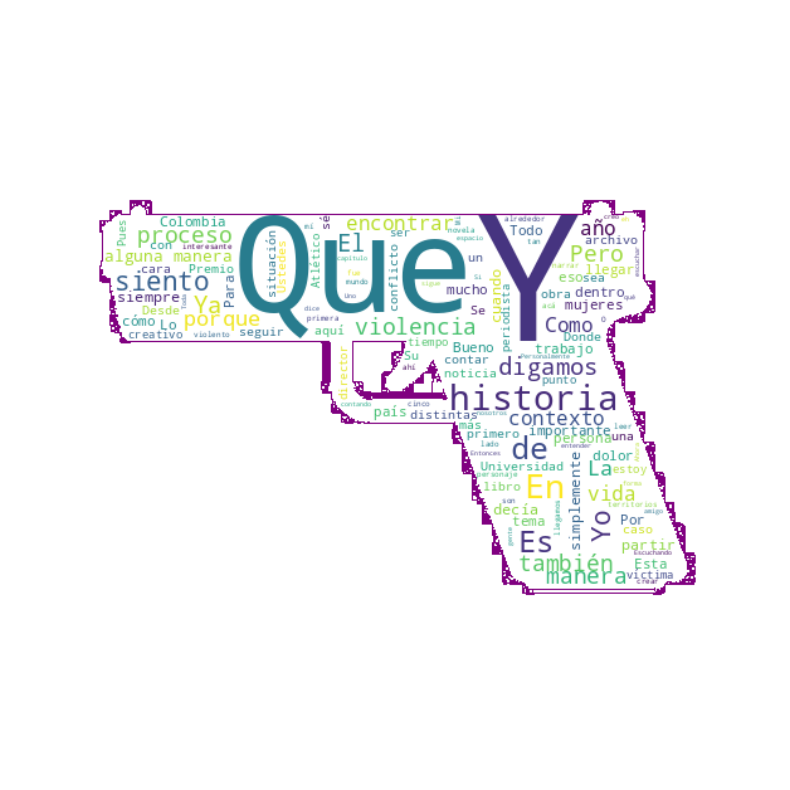

In [18]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

mask_image = np.array(Image.open("/content/drive/MyDrive/Ciencia-Datos/Ulibro/arma.jpg"))

texto_limpio = " ".join(df_limpio["palabra"])

nube = WordCloud(
    background_color="white",
    mask=mask_image,
    contour_width=1,
    contour_color="purple"
).generate(texto_limpio)

plt.figure(figsize=(10, 10))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.show()